# Import modules

In [15]:
from pathlib import Path

import numpy as np
import pandas as pd

import torch
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

from src.dataset import GTZANDataset
from src.beta_vae import BetaVAE, beta_vae_loss
from src.clustering import perform_kmeans
from src.evaluation import evaluate_clustering
from src.visualization import plot_tsne, plot_loss
from src.pca_baseline import run_pca

# Import dataset

In [2]:
# configs
DATASET_PATH = 'data/genres_original'
BATCH_SIZE = 16

# loading dataset
dataset = GTZANDataset(DATASET_PATH)

all_features = []
all_labels = []

for x, y in dataset:
    all_features.append(x.numpy())
    all_labels.append(y)

all_features = np.array(all_features)
all_labels = np.array(all_labels)

# normalise features
scaler = StandardScaler()
all_features = scaler.fit_transform(all_features)

# construct dataloader
tensor_x = torch.tensor(all_features, dtype=torch.float32)
tensor_y = torch.tensor(all_labels)

dataset = TensorDataset(tensor_x, tensor_y)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

/home/tanzim/miniconda3/envs/cse715-project/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/tanzim/Documents/Studies/University/BRAC/Study Related/Semester 3/Assignments/CSE715/project/src/dataset.py:26: UserWarning: PySoundFile failed. Trying audioread instead.
  librosa.load(path, duration=1)
/home/tanzim/miniconda3/envs/cse715-project/lib/python3.14/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Failed to load data/genres_original/jazz/jazz.00054.wav


# PCA baseline

In [ ]:
# apply pca
pca_features, pca_model = run_pca(all_features, n_components=16)
# perform clustering
pca_labels = perform_kmeans(pca_features, k=10)

# evaluation
pca_results = evaluate_clustering(pca_features, pca_labels, all_labels)
print(f'Results for PCA:')
for metric, score in pca_results.items():
    print(f'{metric}: {score}')

# save results
Path('results/pca').mkdir(parents=True, exist_ok=True)

np.save(f'results/pca/pca_features.npy', pca_features)
np.save(f'results/pca/cluster_labels.npy', pca_labels)
np.save(f'results/pca/true_labels.npy', all_labels)

pd.DataFrame([pca_results]).to_csv(f'results/pca/metrics.csv', index=False)

# visualisations
plot_tsne(pca_features, pca_labels, 'Cluster Visualization',
          f'results/pca/clusters.svg')

plot_tsne(pca_features, all_labels, 'True Labels',
          f'results/pca/true_labels.svg')

Results for PCA:
Silhouette: 0.07191251963376999
Calinski: 90.9295950159889
Davies: 2.3528436020662755
ARI: 0.13734723159548345
NMI: 0.257554283504308
Purity: 0.36536536536536535


# VAE-based models

## VAE

In [ ]:
# configs
LATENT_DIM = 16
LR = 1e-3
EPOCHS = 50
BETA = 1

# construct model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = BetaVAE(input_dim=tensor_x.shape[1], latent_dim=LATENT_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# model training
loss_history = []

print('epoch,loss')
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch, _ in dataloader:
        batch = batch.to(device)

        optimizer.zero_grad()
        recon, mu, logvar = model(batch)

        loss = beta_vae_loss(recon, batch, mu, logvar, beta=BETA)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    loss_history.append(total_loss)
    # print(f'{epoch+1},{total_loss:.4f}')

epoch,loss
1,62.8282
2,57.7271
3,55.8443
4,54.4133
5,53.2731
6,52.9293
7,52.2859
8,51.8368
9,51.4968
10,51.2332
11,50.8058
12,50.5946
13,49.9257
14,49.5592
15,49.5759
16,49.3594
17,48.9390
18,48.6032
19,48.6152
20,48.4184
21,48.6478
22,48.7446
23,48.8280
24,48.4927
25,48.7572
26,47.7349
27,47.8968
28,48.0756
29,48.4572
30,47.5683
31,48.0457
32,47.6858
33,47.3693
34,47.7327
35,48.3731
36,47.3015
37,47.8529
38,47.5255
39,47.4870
40,46.9976
41,47.2745
42,47.2857
43,46.8083
44,47.2972
45,47.4336
46,47.2583
47,47.1996
48,47.1521
49,47.2641
50,46.9281


In [5]:
# model evaluation
model.eval()
latent_vectors = []
true_labels = []

with torch.no_grad():
    for batch, labels in dataloader:
        batch = batch.to(device)
        mu, _ = model.encode(batch)

        latent_vectors.append(mu.cpu())
        true_labels.extend(labels.numpy())

latent_vectors = torch.cat(latent_vectors).numpy()

true_labels = np.array(true_labels)

cluster_labels = perform_kmeans(latent_vectors, k=10)

results = evaluate_clustering(latent_vectors, cluster_labels, true_labels)
print(f'Results for VAE with latent_dim={LATENT_DIM} and beta={BETA}:')
for metric, score in results.items():
    print(f'{metric}: {score}')

Results for VAE with latent_dim=16 and beta=1:
Silhouette: 0.2201571762561798
Calinski: 237.050216472542
Davies: 1.316729728972599
ARI: 0.11436037115816443
NMI: 0.2200287021945882
Purity: 0.3263263263263263


In [10]:
# save results
Path(f'results/bvae_{BETA}').mkdir(parents=True, exist_ok=True)

np.save(f'results/bvae_{BETA}/latent_vectors.npy', latent_vectors)
np.save(f'results/bvae_{BETA}/cluster_labels.npy', cluster_labels)
np.save(f'results/bvae_{BETA}/true_labels.npy', true_labels)

pd.DataFrame(enumerate(loss_history, start=1)).to_csv(f'results/bvae_{BETA}/loss_history.csv', index=False, header=['epoch', 'loss'])

pd.DataFrame([results]).to_csv(f'results/bvae_{BETA}/metrics.csv', index=False)

torch.save(model.state_dict(), f'results/bvae_{BETA}/beta_vae.pth')

# visualisations
plot_tsne(latent_vectors, cluster_labels, 'Cluster Visualization', f'results/bvae_{BETA}/clusters.svg')

plot_tsne(latent_vectors, true_labels, 'True Labels', f'results/bvae_{BETA}/true_labels.svg')

plot_loss(loss_history, f'results/bvae_{BETA}/loss_curve.svg')

## Beta-VAE (Beta=2)

In [ ]:
# configs
LATENT_DIM = 16
LR = 1e-3
EPOCHS = 50
BETA = 2

# construct model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = BetaVAE(input_dim=tensor_x.shape[1], latent_dim=LATENT_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# model training
loss_history = []

print('epoch,loss')
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch, _ in dataloader:
        batch = batch.to(device)

        optimizer.zero_grad()
        recon, mu, logvar = model(batch)

        loss = beta_vae_loss(recon, batch, mu, logvar, beta=BETA)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    loss_history.append(total_loss)
    # print(f'{epoch+1},{total_loss:.4f}')

# model evaluation
model.eval()
latent_vectors = []
true_labels = []

with torch.no_grad():
    for batch, labels in dataloader:
        batch = batch.to(device)
        mu, _ = model.encode(batch)

        latent_vectors.append(mu.cpu())
        true_labels.extend(labels.numpy())

latent_vectors = torch.cat(latent_vectors).numpy()

true_labels = np.array(true_labels)

cluster_labels = perform_kmeans(latent_vectors, k=10)

results = evaluate_clustering(latent_vectors, cluster_labels, true_labels)
print(f'Results for VAE with latent_dim={LATENT_DIM} and beta={BETA}:')
for metric, score in results.items():
    print(f'{metric}: {score}')

# save results
Path(f'results/bvae_{BETA}').mkdir(parents=True, exist_ok=True)

np.save(f'results/bvae_{BETA}/latent_vectors.npy', latent_vectors)
np.save(f'results/bvae_{BETA}/cluster_labels.npy', cluster_labels)
np.save(f'results/bvae_{BETA}/true_labels.npy', true_labels)

pd.DataFrame(enumerate(loss_history, start=1)).to_csv(f'results/bvae_{BETA}/loss_history.csv', index=False, header=['epoch', 'loss'])

pd.DataFrame([results]).to_csv(f'results/bvae_{BETA}/metrics.csv', index=False)

torch.save(model.state_dict(), f'results/bvae_{BETA}/beta_vae.pth')

# visualisations
plot_tsne(latent_vectors, cluster_labels, 'Cluster Visualization', f'results/bvae_{BETA}/clusters.svg')

plot_tsne(latent_vectors, true_labels, 'True Labels', f'results/bvae_{BETA}/true_labels.svg')

plot_loss(loss_history, f'results/bvae_{BETA}/loss_curve.svg')

epoch,loss
1,63.8011
2,63.0439
3,62.9288
4,61.1433
5,60.3749
6,60.0863
7,59.6492
8,59.4059
9,58.3238
10,58.3548
11,57.8060
12,58.3781
13,57.9593
14,57.3145
15,57.3217
16,57.0585
17,57.3181
18,56.5402
19,56.4336
20,56.5970
21,55.8794
22,55.9423
23,55.8137
24,55.8815
25,56.5824
26,56.0271
27,56.2759
28,56.3531
29,55.7887
30,56.0753
31,55.9965
32,55.6556
33,55.9356
34,56.2939
35,55.5843
36,56.1178
37,55.6094
38,55.4842
39,55.1579
40,55.5830
41,55.4167
42,55.3037
43,55.1389
44,55.7574
45,54.9275
46,55.1336
47,55.2444
48,55.2772
49,55.1573
50,55.5272
Results for VAE with latent_dim=16 and beta=2:
Silhouette: 0.34979450702667236
Calinski: 972.8577581892536
Davies: 0.8513128632510429
ARI: 0.12768885172066685
NMI: 0.24051605831399547
Purity: 0.34934934934934936


## Beta-VAE (Beta=4)

In [ ]:
# configs
LATENT_DIM = 16
LR = 1e-3
EPOCHS = 50
BETA = 4

# construct model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = BetaVAE(input_dim=tensor_x.shape[1], latent_dim=LATENT_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# model training
loss_history = []

print('epoch,loss')
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch, _ in dataloader:
        batch = batch.to(device)

        optimizer.zero_grad()
        recon, mu, logvar = model(batch)

        loss = beta_vae_loss(recon, batch, mu, logvar, beta=BETA)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    loss_history.append(total_loss)
    # print(f'{epoch+1},{total_loss:.4f}')

# model evaluation
model.eval()
latent_vectors = []
true_labels = []

with torch.no_grad():
    for batch, labels in dataloader:
        batch = batch.to(device)
        mu, _ = model.encode(batch)

        latent_vectors.append(mu.cpu())
        true_labels.extend(labels.numpy())

latent_vectors = torch.cat(latent_vectors).numpy()

true_labels = np.array(true_labels)

cluster_labels = perform_kmeans(latent_vectors, k=10)

results = evaluate_clustering(latent_vectors, cluster_labels, true_labels)
print(f'Results for VAE with latent_dim={LATENT_DIM} and beta={BETA}:')
for metric, score in results.items():
    print(f'{metric}: {score}')

# save results
Path(f'results/bvae_{BETA}').mkdir(parents=True, exist_ok=True)

np.save(f'results/bvae_{BETA}/latent_vectors.npy', latent_vectors)
np.save(f'results/bvae_{BETA}/cluster_labels.npy', cluster_labels)
np.save(f'results/bvae_{BETA}/true_labels.npy', true_labels)

pd.DataFrame(enumerate(loss_history, start=1)).to_csv(f'results/bvae_{BETA}/loss_history.csv', index=False, header=['epoch', 'loss'])

pd.DataFrame([results]).to_csv(f'results/bvae_{BETA}/metrics.csv', index=False)

torch.save(model.state_dict(), f'results/bvae_{BETA}/beta_vae.pth')

# visualisations
plot_tsne(latent_vectors, cluster_labels, 'Cluster Visualization', f'results/bvae_{BETA}/clusters.svg')

plot_tsne(latent_vectors, true_labels, 'True Labels', f'results/bvae_{BETA}/true_labels.svg')

plot_loss(loss_history, f'results/bvae_{BETA}/loss_curve.svg')

epoch,loss
1,63.7904
2,63.4360
3,63.1765
4,63.0140
5,63.1772
6,63.2857
7,63.0293
8,63.4063
9,62.6575
10,62.5692
11,62.4300
12,62.9286
13,61.8440
14,62.3551
15,62.0341
16,62.6962
17,62.1137
18,62.3810
19,62.3598
20,61.9650
21,61.7247
22,62.2182
23,61.9804
24,62.3856
25,62.0390
26,62.6087
27,62.1825
28,62.2991
29,61.5386
30,61.3511
31,62.2428
32,60.8756
33,61.8345
34,61.3196
35,61.9239
36,61.3583
37,62.3868
38,61.6521
39,61.5302
40,61.1382
41,61.2588
42,60.7269
43,61.3432
44,61.6705
45,61.6292
46,61.7921
47,61.3994
48,60.6245
49,61.6155
50,61.0399
Results for VAE with latent_dim=16 and beta=4:
Silhouette: 0.5454503297805786
Calinski: 11369.127579189953
Davies: 0.5198037774262938
ARI: 0.08537181434922081
NMI: 0.18808751244006364
Purity: 0.2822822822822823


# Results

In [35]:
# evaluation metrics
df = pd.concat((
        pd.read_csv('results/pca/metrics.csv'),
        pd.read_csv('results/bvae_1/metrics.csv'),
        pd.read_csv('results/bvae_2/metrics.csv'),
        pd.read_csv('results/bvae_4/metrics.csv')
    ))

df.index = ['PCA', 'VAE', 'Beta-VAE (Beta=2)', 'Beta-VAE (Beta=4)']

df

,Silhouette,Calinski,Davies,ARI,NMI,Purity
PCA,0.071913,90.929595,2.352844,0.137347,0.257554,0.365365
VAE,0.220157,237.050216,1.316730,0.114360,0.220029,0.326326
Beta-VAE (Beta=2),0.349795,972.857758,0.851313,0.127689,0.240516,0.349349
Beta-VAE (Beta=4),0.545450,11369.127579,0.519804,0.085372,0.188088,0.282282


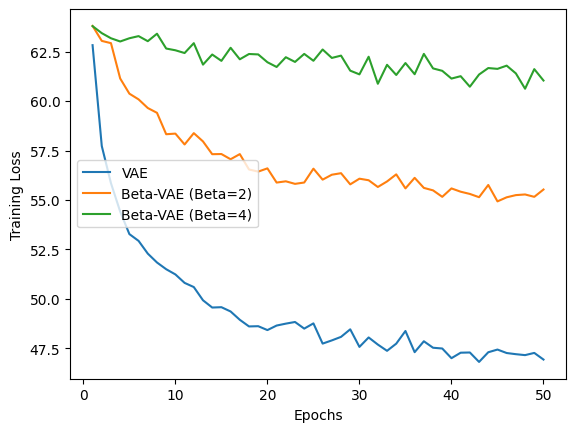

In [ ]:
# visualise training loss for vae models
df = pd.read_csv('results/bvae_1/loss_history.csv')
plt.plot(df['epoch'], df['loss'])
df = pd.read_csv('results/bvae_2/loss_history.csv')
plt.plot(df['epoch'], df['loss'])
df = pd.read_csv('results/bvae_4/loss_history.csv')
plt.plot(df['epoch'], df['loss'])

plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.legend(['VAE', 'Beta-VAE (Beta=2)', 'Beta-VAE (Beta=4)'])
plt.show()